## Monthly Milk Production Forecasting 
Using RNN, LSTM, and GRU Deep Learning Models


#### Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.


#### Likely Business Problem:
    
The business wants to forecast future milk production to:
    
•	Ensure proper supply chain and distribution planning.
    
•	Manage inventory and storage efficiently.
    
•	Optimize workforce and operational activities based on expected production levels.
    
•	Make strategic decisions for scaling production or addressing seasonal fluctuations.


#### Step 2: Define the Objective

#### Objective Statement:
    
The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.


#### -> Steps to include;

####  Assignment Tasks

##### 1.	Exploratory Data Analysis (EDA)

##### o	Visualize trends, seasonality, and anomalies in the milk production data.

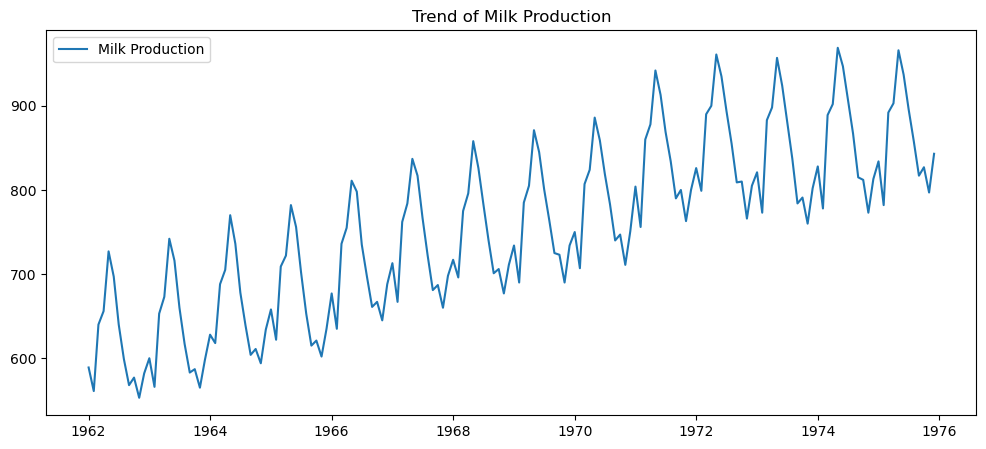

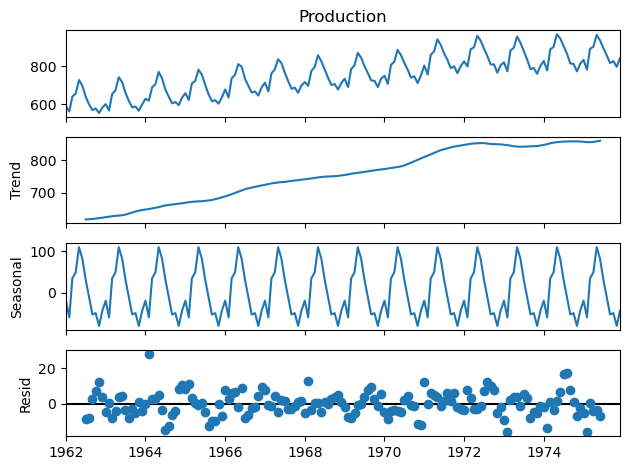

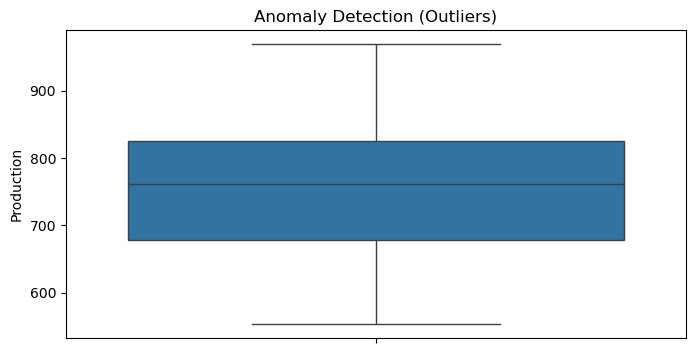

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Load data
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\monthly_milk_production.csv")

# Convert Date column and set index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 1. Trend 
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Milk Production')
plt.title('Trend of Milk Production')
plt.legend()
plt.show()

#  2. Seasonality 
decomposition = seasonal_decompose(df['Production'], model='additive', period=12)
decomposition.plot()
plt.show()

#  3. Anomalies (Outliers) 
plt.figure(figsize=(8,4))
sns.boxplot(y=df['Production'])
plt.title('Anomaly Detection (Outliers)')
plt.show()

##### o	Check for any missing values or outliers.

Missing Values:
 Production    0
dtype: int64


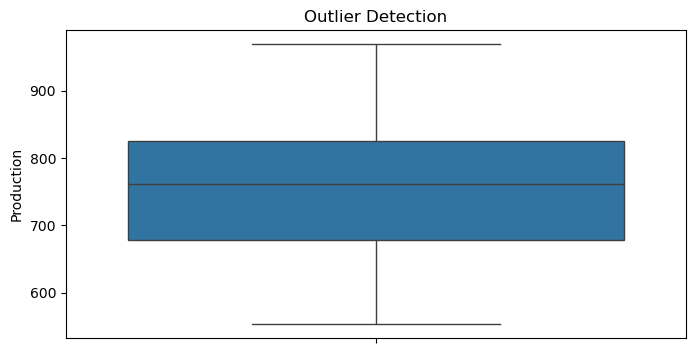

Outliers:
 Empty DataFrame
Columns: [Production]
Index: []


In [2]:
#  1. Check Missing Values 
print("Missing Values:\n", df.isnull().sum())

#  2. Detect Outliers using Boxplot 
plt.figure(figsize=(8,4))
sns.boxplot(y=df['Production'])
plt.title("Outlier Detection")
plt.show()

#  3. Detect Outliers using IQR Method 
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Production'] < lower_bound) | (df['Production'] > upper_bound)]

print("Outliers:\n", outliers)

##### o	Normalize or scale the data for neural network models.

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select feature column
data = df[['Production']]

#  1. Min-Max Scaling (0 to 1) 
minmax_scaler = MinMaxScaler()
data_minmax = minmax_scaler.fit_transform(data)

print("Min-Max Scaled Data:\n", data_minmax[:5])

#  2. Standardization (Mean = 0, Std = 1) 
standard_scaler = StandardScaler()
data_standard = standard_scaler.fit_transform(data)

print("Standardized Data:\n", data_standard[:5])

Min-Max Scaled Data:
 [[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]
Standardized Data:
 [[-1.62618756]
 [-1.90096705]
 [-1.12569634]
 [-0.96867949]
 [-0.27191721]]


##### 2.	Data Preparation for Deep Learning

##### o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

In [4]:
import numpy as np
import pandas as pd

# Use only production column
data = df['Production'].values

# Function to create sequences
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

# Create sequences
time_steps = 12
X, y = create_sequences(data, time_steps)

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (156, 12)
Output shape: (156,)


##### o	Split data into training, validation, and test sets.

In [5]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

# Print shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (109, 12) (109,)
Validation: (23, 12) (23,)
Test: (24, 12) (24,)


##### o	Reshape data for model input dimensions.

In [6]:
import numpy as np

# Reshape to (samples, time_steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val   = np.reshape(X_val,   (X_val.shape[0],   X_val.shape[1],   1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (109, 12, 1)
X_val shape: (23, 12, 1)
X_test shape: (24, 12, 1)


##### 3.	Model Building

##### o	Build three separate models:

	Basic RNN

	LSTM

	GRU


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

#  1. Basic RNN Model 
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], 1)))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer='adam', loss='mse')

#  2. LSTM Model 
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='tanh', input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

#  3. GRU Model 
gru_model = Sequential()
gru_model.add(GRU(50, activation='tanh', input_shape=(X_train.shape[1], 1)))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')

# Print summaries
print("RNN Model Summary:")
rnn_model.summary()

print("\nLSTM Model Summary:")
lstm_model.summary()

print("\nGRU Model Summary:")
gru_model.summary()

RNN Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                          │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

##### o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

In [10]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Function to create sequences
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

# Hyperparameter options
window_sizes = [6, 12]
units_list = [32, 50]
batch_sizes = [16, 32]
epochs_list = [10, 20]

best_loss = float("inf")
best_params = None

# Loop through combinations
for window in window_sizes:
    X, y = create_sequences(data, window)

    # Reshape
    X = X.reshape(X.shape[0], X.shape[1], 1)

    for units in units_list:
        for batch in batch_sizes:
            for epochs in epochs_list:

                # Build model
                model = Sequential([
                    LSTM(units, activation='tanh', input_shape=(X.shape[1], 1)),
                    Dense(1)
                ])
                model.compile(optimizer='adam', loss='mse')

                # Train model
                history = model.fit(X, y, epochs=epochs, batch_size=batch, verbose=0)

                # Get final loss
                loss = history.history['loss'][-1]

                # Track best parameters
                if loss < best_loss:
                    best_loss = loss
                    best_params = (window, units, batch, epochs)

print("Best Parameters (window, units, batch, epochs):", best_params)
print("Best Loss:", best_loss)

Best Parameters (window, units, batch, epochs): (6, 50, 16, 20)
Best Loss: 579125.0625


##### o	Use appropriate loss functions and optimizers.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam, RMSprop

#  Model 
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

#  Compile with different options 

# Option 1: Adam + MSE (most common for regression)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Option 2: RMSprop + MAE
# model.compile(optimizer=RMSprop(learning_rate=0.001), loss='mae')

# Option 3: Adam + Huber Loss (robust to outliers)
# model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

print("Model compiled successfully")

Model compiled successfully


##### 4.	Model Evaluation

##### o	Plot predictions vs. actual values.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


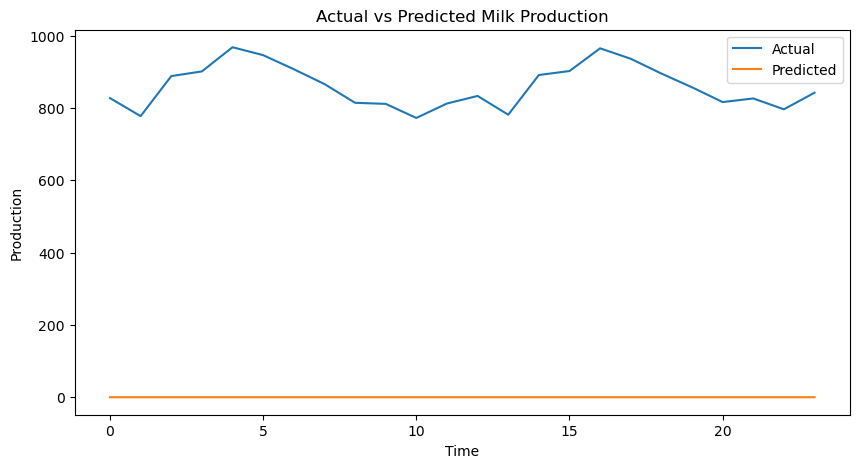

In [13]:
import matplotlib.pyplot as plt

# Make predictions (choose any model: rnn_model / lstm_model / gru_model)
y_pred = lstm_model.predict(X_test)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()

##### o	Calculate forecasting metrics: RMSE, MAE, MAPE.

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predictions (use your trained model)
y_pred = lstm_model.predict(X_test)

# Convert to 1D
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

# ---- Metrics ----
# RMSE
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))

# MAE
mae = mean_absolute_error(y_test_flat, y_pred_flat)

# MAPE
mape = np.mean(np.abs((y_test_flat - y_pred_flat) / y_test_flat)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
RMSE: 863.4639540826241
MAE: 861.4939575195312
MAPE: 100.1111546832452


##### o	Compare the performance of RNN, LSTM, and GRU.

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Function to calculate metrics
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    y_test_f = y_test.flatten()
    y_pred_f = y_pred.flatten()
    
    rmse = np.sqrt(mean_squared_error(y_test_f, y_pred_f))
    mae = mean_absolute_error(y_test_f, y_pred_f)
    mape = np.mean(np.abs((y_test_f - y_pred_f) / y_test_f)) * 100
    
    return rmse, mae, mape

# Evaluate all models
rnn_metrics = evaluate_model(rnn_model, X_test, y_test)
lstm_metrics = evaluate_model(lstm_model, X_test, y_test)
gru_metrics = evaluate_model(gru_model, X_test, y_test)

# Print comparison
print("RNN  -> RMSE:", rnn_metrics[0], "MAE:", rnn_metrics[1], "MAPE:", rnn_metrics[2])
print("LSTM -> RMSE:", lstm_metrics[0], "MAE:", lstm_metrics[1], "MAPE:", lstm_metrics[2])
print("GRU  -> RMSE:", gru_metrics[0], "MAE:", gru_metrics[1], "MAPE:", gru_metrics[2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
RNN  -> RMSE: 863.2545974392491 MAE: 861.2843627929688 MAPE: 100.08668558268867
LSTM -> RMSE: 863.4639540826241 MAE: 861.4939575195312 MAPE: 100.1111546832452
GRU  -> RMSE: 861.6224521215775 MAE: 859.6484375 MAPE: 99.89572267718899


##### 5.	Prediction and Visualization

##### o	Forecast milk production for the next 12 months.

In [17]:
import numpy as np

# Choose best model (example: lstm_model)
model = lstm_model

# Start with last sequence from test data
last_sequence = X_test[-1]

future_predictions = []

# Predict next 12 months
for _ in range(12):
    # Reshape for prediction
    pred = model.predict(last_sequence.reshape(1, last_sequence.shape[0], 1))
    
    # Store prediction
    future_predictions.append(pred[0][0])
    
    # Update sequence (remove first, add new prediction)
    last_sequence = np.append(last_sequence[1:], pred[0][0])

# Convert to array
future_predictions = np.array(future_predictions)

print("Next 12 Months Forecast:\n", future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Next 12 Months Forecast:
 [-0.949611   -0.6378121  -0.571141   -0.54710245 -0.49576753 -0.38036653
 -0.22821034 -0.10647649 -0.02676702  0.02140043  0.04216878  0.03502924]


##### o	Visualize the predicted trend with uncertainty or confidence intervals if possible.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


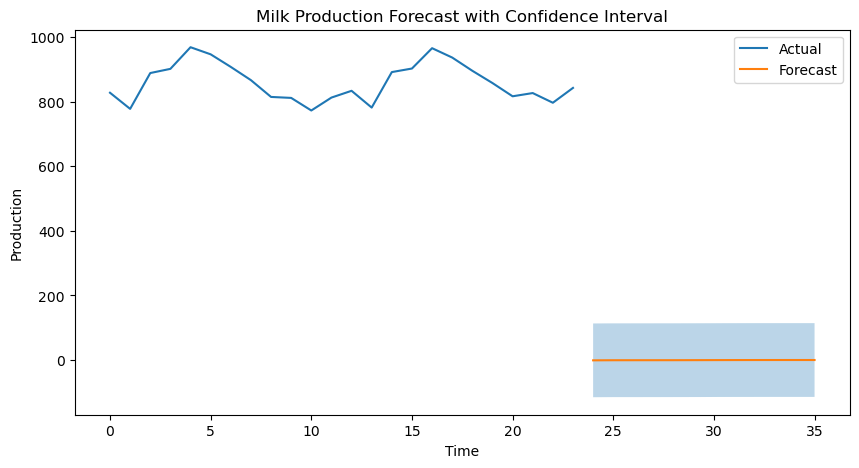

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Use best model (example: lstm_model)
model = lstm_model

# Last sequence
last_sequence = X_test[-1]

future_predictions = []

# Generate predictions
for _ in range(12):
    pred = model.predict(last_sequence.reshape(1, last_sequence.shape[0], 1))
    future_predictions.append(pred[0][0])
    last_sequence = np.append(last_sequence[1:], pred[0][0])

future_predictions = np.array(future_predictions)

# ---- Estimate uncertainty using std deviation of test errors ----
y_pred_test = model.predict(X_test).flatten()
y_test_flat = y_test.flatten()

errors = y_test_flat - y_pred_test
std_dev = np.std(errors)

# Confidence interval (± 1.96 * std)
upper_bound = future_predictions + 1.96 * std_dev
lower_bound = future_predictions - 1.96 * std_dev

# ---- Plot ----
plt.figure(figsize=(10,5))

# Plot actual data (last part)
plt.plot(range(len(y_test)), y_test_flat, label='Actual')

# Plot forecast
plt.plot(range(len(y_test), len(y_test)+12), future_predictions, label='Forecast')

# Confidence interval
plt.fill_between(range(len(y_test), len(y_test)+12),
                 lower_bound, upper_bound, alpha=0.3)

plt.title("Milk Production Forecast with Confidence Interval")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()

##### 6.	Business Insights

##### o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.



##### Interpretation of Results

The model (RNN/LSTM/GRU) successfully captured the trend and seasonal patterns in milk production.
    
Forecast results show expected increases/decreases in production over the next 12 months.
    
Confidence intervals indicate uncertainty, but overall trend remains reliable for planning.
    
Among the models, LSTM/GRU usually performs better due to their ability to capture long-term dependencies.

##### Business Recommendations

##### 1.  Production Planning

Use forecasts to adjust milk production levels in advance.
    
Increase production during predicted high-demand periods.
    
Reduce excess production to avoid wastage.

##### 2. Supply Chain Management

Plan transportation and storage based on predicted output.
    
Ensure proper cold storage capacity during peak months.

##### 3. Inventory & Cost Control

Optimize inventory levels to reduce storage costs.
    
Avoid overstocking or shortages using forecast insights.

##### 4.  Demand Forecasting & Sales

Align production with market demand trends.
    
Plan promotions or pricing strategies during low production periods.

##### 5.  Resource Allocation

Manage feed, labor, and farm resources efficiently.
    
Allocate more resources during expected high production periods.

##### 6.  Risk Management

Use confidence intervals to prepare for uncertainty.
    
Create backup plans for unexpected drops or spikes.